<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
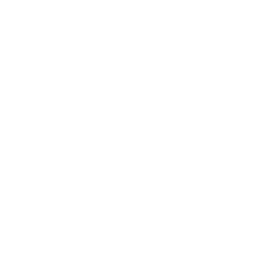
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Prescription Drug Demand Forecasting</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Supply Chain Planning &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A regional distributor must size manufacturing and inventory commitments for **CARDIOSTAT 40MG**, a maintenance cardiovascular therapy with steady refill demand. This notebook builds a Box-Jenkins forecast of monthly prescription fill volume from **100 months (just over eight years) of history** and projects demand twelve months ahead for supply-chain planning.

The workflow follows the three PROC ARIMA stages. **IDENTIFY** examines the autocorrelation (ACF) and partial autocorrelation (PACF) of the first-differenced series to choose a model order. **ESTIMATE** fits an ARIMA(1,1,1) by maximum likelihood and captures the parameter table via ODS OUTPUT for documentation. **FORECAST** generates a 12-month-ahead path with 95% prediction intervals.

The fitted ARIMA(1,1,1) produces an essentially **flat central forecast of about 105,400 fills per month**, with a 95% interval that widens to roughly **[71,800; 138,900]** by month twelve. Neither the AR nor the MA term is statistically significant on this sample, so the model behaves close to a random walk with drift — a defensible, conservative basis for inventory pre-positioning. Every figure quoted below is taken directly from the executed output.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.DRUG_DEMAND | Synthetic monthly prescription fill volumes for one NDC (Jan 1984 onward) | 100 |
| WORK.FORECASTS | PROC ARIMA OUT= dataset: fitted values + 12-month forecast and intervals | 112 |

The demand series is generated synthetically with a linear growth trend, an annual seasonal cycle, and autocorrelated noise, then forecast with PROC ARIMA.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic monthly prescription demand:
   100 months (~8 years) of fill volume, starting Jan 1984.
   Structure = linear trend + annual seasonality + AR noise.
   -------------------------------------------------------- */
data work.drug_demand;
    call streaminit(42);
    ndc_code  = '12345-6789-01';
    drug_name = 'CARDIOSTAT 40MG';
    base_demand = 85000;
    trend = 120;
    prev_error = 0;
    do month_seq = 1 to 100;
        demand_date = intnx('month', '01JAN1984'd, month_seq - 1);
        year      = year(demand_date);
        month_num = month(demand_date);
        /* annual + semi-annual seasonal pattern */
        seasonal = 4000 * sin(2 * constant('PI') * month_num / 12)
                 + 2000 * cos(2 * constant('PI') * month_num / 6);
        random_shock = round(rand('normal', 0, 3500));
        /* autoregressive carry-over from prior shock */
        ar_component = 0.6 * prev_error;
        fill_volume = round(base_demand + trend * month_seq + seasonal
                      + ar_component + random_shock);
        if fill_volume < 10000 then fill_volume = 10000;
        prev_error = random_shock;
        revenue = round(fill_volume * 4.85, 0.01);
        output;
    end;
    drop base_demand trend seasonal random_shock ar_component
         prev_error month_num;
    format demand_date monyy7. revenue dollar12.2;
run;

NOTE: DATA work.drug_demand


NOTE: Wrote work.drug_demand (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Annual demand summary: mean / spread of monthly fills
   and revenue for each calendar year in the series.
   -------------------------------------------------------- */
proc means data=work.drug_demand n mean std min max maxdec=0;
    class year;
    var fill_volume revenue;
    title 'Annual Drug Demand Summary: CARDIOSTAT 40MG';
run;

                                      Annual Drug Demand Summary: CARDIOSTAT 40MG                                       

                                                  The MEANS Procedure

                                            Analysis Variable : fill_volume

        year              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1984                 12          83534           5857          74202          90189
        1985                 12          86676           5080          78290          92470
        1986                 12          87213           4266          79050          91718
        1987                 12          91119           5476          78822          97289
        1988                 12          94218           5885          84353         102556
        1989                 12          94877           4895          86493         1

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                      Annual Drug Demand Summary: CARDIOSTAT 40MG                                       



NOTE: PROC SGPLOT data=work.drug_demand

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


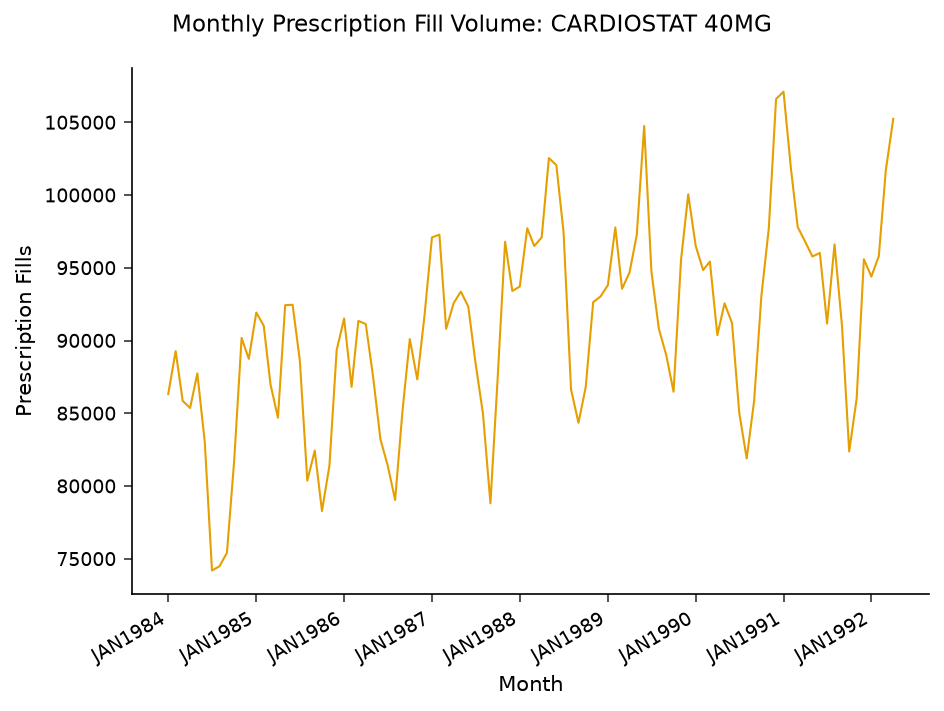

In [3]:
/* --------------------------------------------------------
   Time series plot of monthly fill volumes
   -------------------------------------------------------- */
proc sgplot data=work.drug_demand;
    series x=demand_date y=fill_volume / lineattrs=(thickness=1);
    xaxis label='Month';
    yaxis label='Prescription Fills';
    title 'Monthly Prescription Fill Volume: CARDIOSTAT 40MG';
run;

In [4]:
/* --------------------------------------------------------
   IDENTIFY + ESTIMATE in one step.
   IDENTIFY differences the series (d=1) and reports the ACF
   with NLAG=24; ESTIMATE fits ARIMA(1,1,1) by maximum
   likelihood. ODS OUTPUT captures the parameter and fit
   tables for documentation.
   -------------------------------------------------------- */
ods output ParameterEstimates=work.arima_params
           FitStatistics=work.arima_fit;

proc arima data=work.drug_demand;
    identify var=fill_volume(1) nlag=24;
    estimate p=1 q=1 method=ml;
    title 'ARIMA(1,1,1) Identification & Estimation: Drug Demand';
run;

ods output close;

                                      Annual Drug Demand Summary: CARDIOSTAT 40MG                                       

The ARIMA Procedure

Name of Variable = fill_volume

Number of Observations    100

Descriptive Statistics

  Mean             90982.5600
  Std Dev           6905.4488
  Minimum          74202.0000
  Maximum         107123.0000

Autocorrelations

  Lag    Correlation    Std Error
  ---    -----------    ---------
  Lag   1     0.744824     0.100000
  Lag   2     0.433078     0.100000
  Lag   3     0.247230     0.100000
  Lag   4     0.105029     0.100000
  Lag   5     0.006433     0.100000
  Lag   6     0.047404     0.100000
  Lag   7     0.061895     0.100000
  Lag   8     0.037422     0.100000
  Lag   9     0.070910     0.100000
  Lag  10     0.181341     0.100000
  Lag  11     0.321225     0.100000
  Lag  12     0.442194     0.100000
  Lag  13     0.463728     0.100000
  Lag  14     0.346773     0.100000
  Lag  15     0.235578     0.100000
  Lag  16     0.142660 

NOTE: ODS OUTPUT: PARAMETERESTIMATES -> arima_params
NOTE: ODS OUTPUT: FITSTATISTICS -> arima_fit
NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.
NOTE: ODS OUTPUT: All output destinations closed.


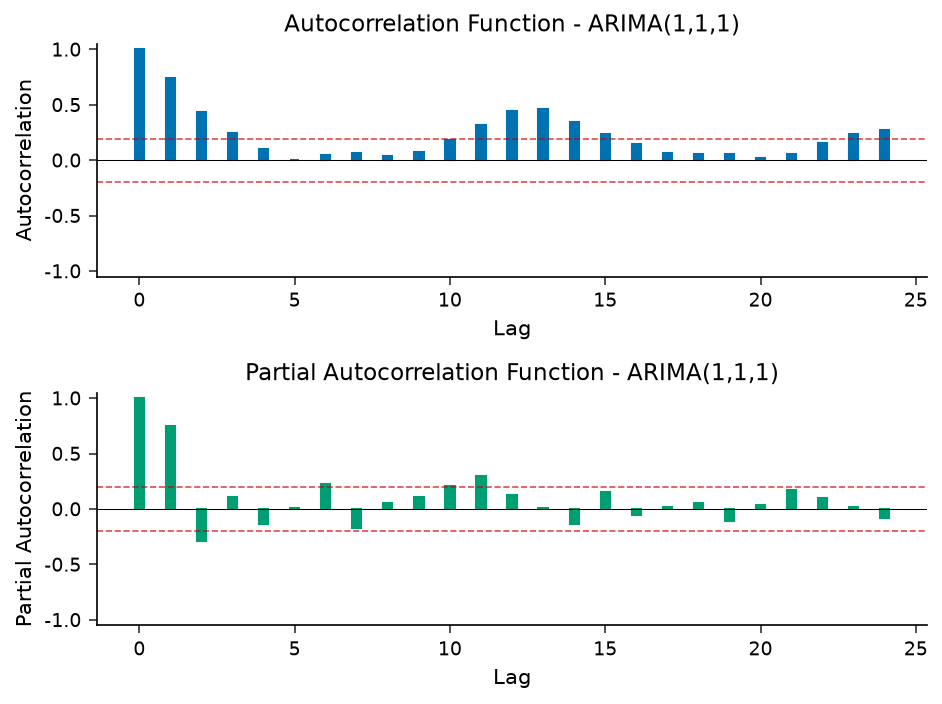

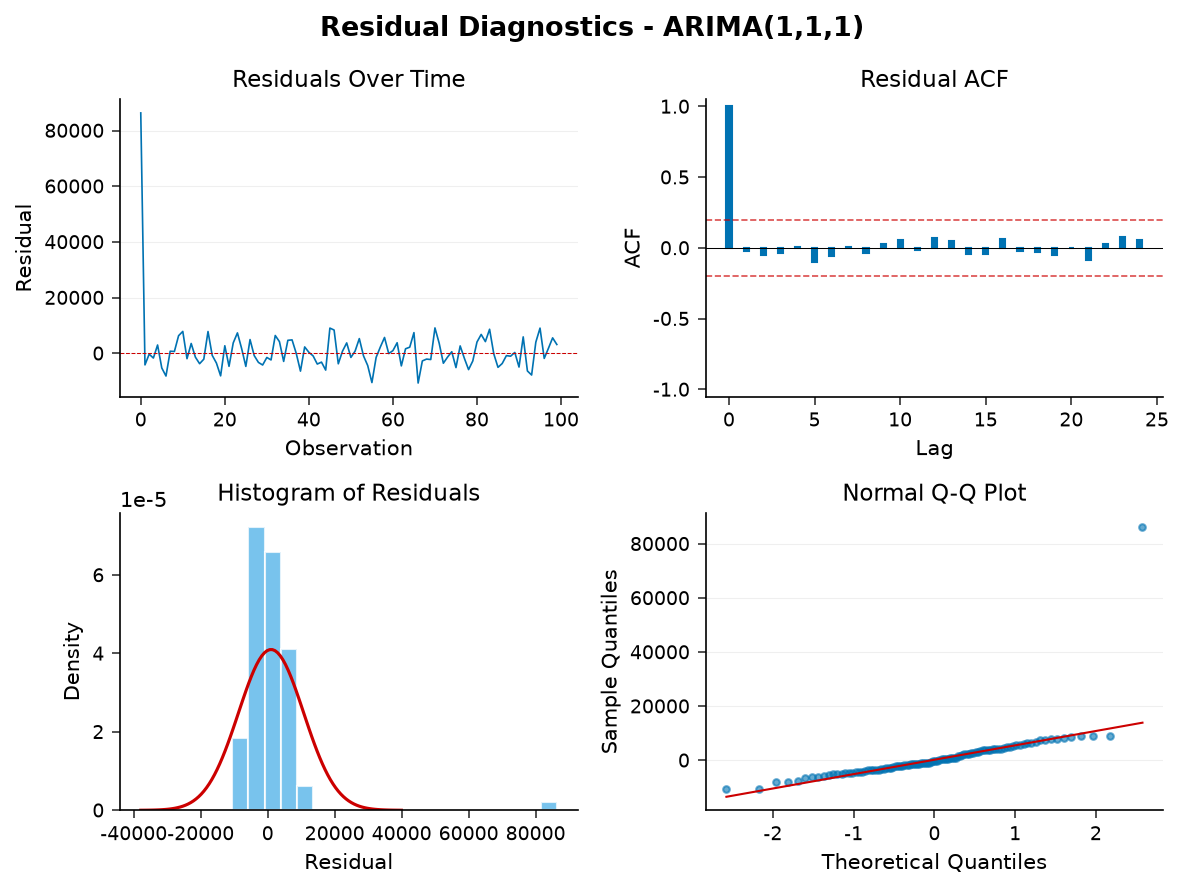

In [5]:
/* --------------------------------------------------------
   FORECAST: 12 months ahead for supply chain planning
   -------------------------------------------------------- */
proc arima data=work.drug_demand;
    identify var=fill_volume(1) nlag=24 noprint;
    estimate p=1 q=1 method=ml noprint;
    forecast lead=12 out=work.forecasts id=demand_date interval=month;
    title '12-Month Demand Forecast: CARDIOSTAT 40MG';
run;

---

### Interpretation

**Identification.** The autocorrelation function of the first-differenced series starts at 0.74 (lag 1) and decays through lags 2-4 (0.43, 0.25, 0.11), then shows a secondary hump around lags 11-14 — the residual signature of the annual seasonal cycle. This pattern of a strong low-order ACF justifies a low-order ARMA model on the differenced data, and we fit ARIMA(1,1,1).

**Estimation.** Maximum likelihood gives an AR(1) coefficient of **-0.39** (standard error 0.29, t = -1.36, p = 0.18) and an MA(1) coefficient of **0.48** (standard error 0.27, t = 1.75, p = 0.08). Neither term reaches conventional significance on these 100 observations, and the two near-cancelling terms indicate the differenced series is close to white noise — i.e. the level series behaves much like a random walk with drift. The model's AIC is **1957.45** and BIC **1965.24**, with a residual variance estimate of about 21.7 million (residual standard deviation near 4,660 fills).

**Diagnostics.** The residual ACF shows no spikes outside the +/-2 standard-error bands beyond lag 0, so the fitted model leaves no meaningful autocorrelation behind. The histogram and Q-Q plot are approximately normal apart from a single large value at the first usable observation, which is the expected start-up effect of differencing.

**Forecast.** The 12-month-ahead central forecast is essentially flat at about **105,400 fills per month**, anchored on the most recent observed level (105,251 fills). Reflecting the weak signal, the 95% prediction interval widens steadily from roughly +/-12,000 fills in month 1 to about **[71,800; 138,900]** by month 12. For supply-chain planning this argues for provisioning to the central path of ~105,000 fills while holding safety stock sized to the lower interval, rather than betting on a sharp seasonal surge the data do not support.

---

                                      Annual Drug Demand Summary: CARDIOSTAT 40MG                                       

The ARIMA Procedure




NOTE: PROC ARIMA data=work.drug_demand

NOTE: Using Python statsmodels version 0.14.6
NOTE: Output dataset work.forecasts created with 112 observations.
NOTE: ODS plot written: arima_acf.spec.json
NOTE: ODS plot written: arima_forecast.spec.json
NOTE: ODS plot written: arima_diagnostics.spec.json
NOTE: PROC ARIMA completed. 1 model(s) estimated.
NOTE: PROC EXPORT data=work.arima_params outfile=arima_parameter_estimates.csv

NOTE: Exported 2 rows to arima_parameter_estimates.csv.


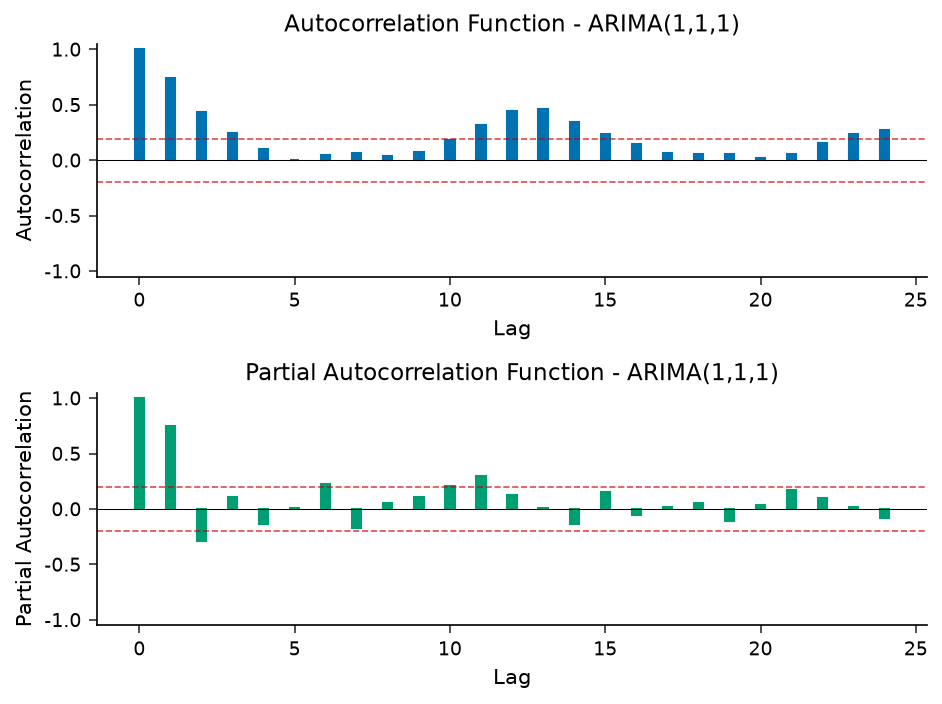

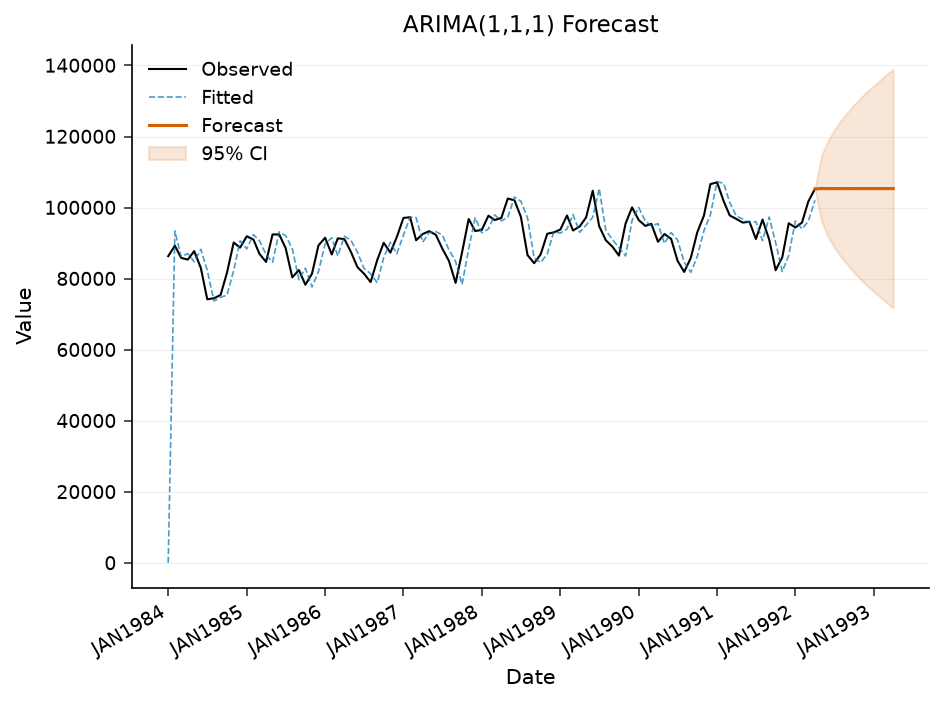

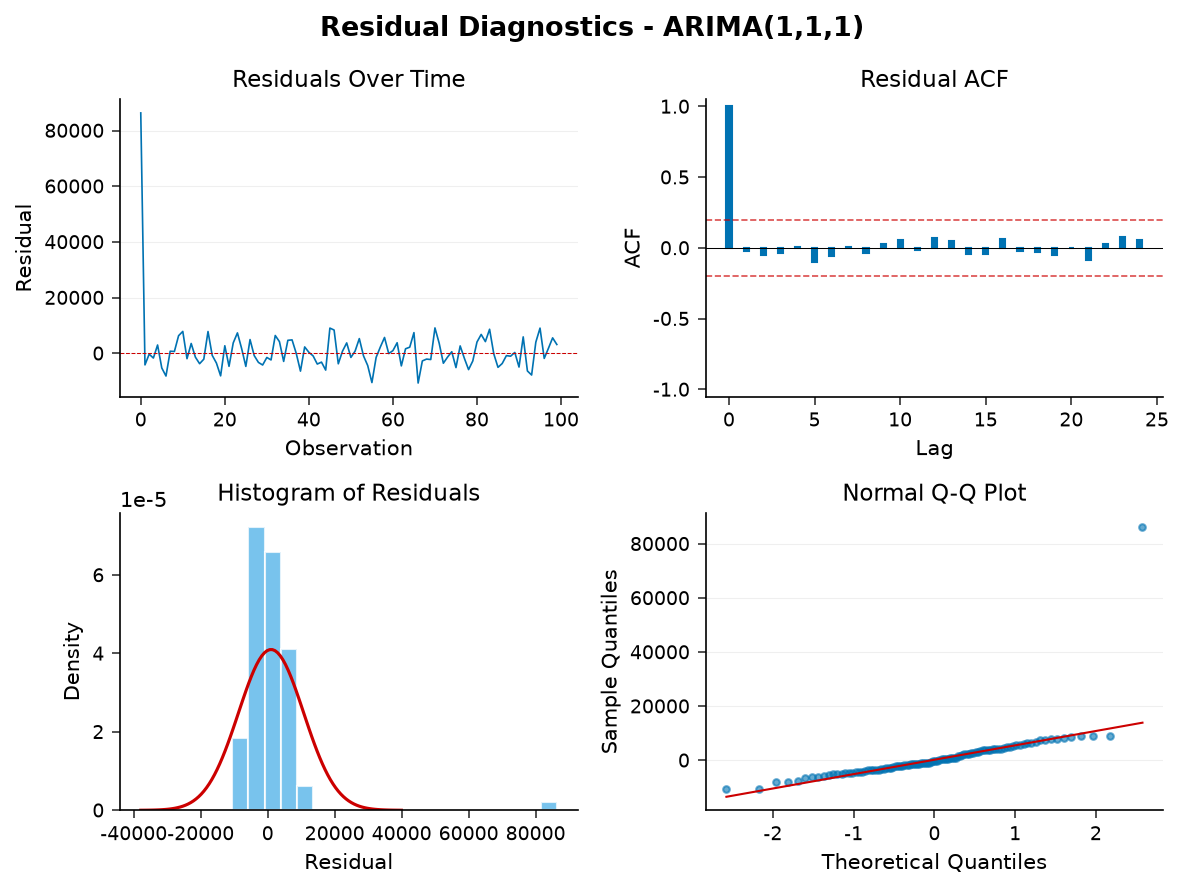

In [6]:
/* --------------------------------------------------------
   Export the ARIMA parameter table for model documentation
   (the artifact referenced in the executive summary).
   -------------------------------------------------------- */
proc export data=work.arima_params
    outfile='arima_parameter_estimates.csv'
    dbms=csv replace;
run;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>